"quais fatores operacionais realmente influenciam a satisfação do cliente e como a empresa pode agir de forma proativa para melhorar a experiência antes mesmo da aplicação da pesquisa de NPS?"

Vamos agora importar as bibliotécas e o nosso banco de dados.

In [45]:
#Libs

import pandas as pd
import numpy as np

#libs gráficas
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

#Avisos
import warnings
warnings.filterwarnings('ignore')

In [46]:
df_nps = pd.read_csv('/content/desafio_nps_fase_1.csv')
display(df_nps.head())

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


Iniciaremos um estudo sobre a estrutura dos dados, tipo das colunas e quantidade de elementos nulos

In [47]:
print(f'Tamanho do nosso Dataset (Linhas, Colunas): {df_nps.shape}')

Tamanho do nosso Dataset (Linhas, Colunas): (2500, 19)


In [48]:
df_nps.dtypes

,0
customer_id,int64
customer_age,int64
customer_region,object
customer_tenure_months,int64
order_id,int64
order_value,float64
items_quantity,int64
discount_value,float64
payment_installments,int64
delivery_time_days,int64


In [49]:
print(f'Quantidade de dados nulos no nosso dataframe (base de dados): {df_nps.isnull().sum().sum()}')

Quantidade de dados nulos no nosso dataframe (base de dados): 0


In [50]:
df_nps.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

Feito o estudo inicial, vamos agora retirar as colunas de indentificadores que não interferem na análise. Além disso vamos entender como as classes de NPS se distribuem na base

In [51]:
df_nps = df_nps.drop(columns=['customer_id', 'order_id'])
display(df_nps.head())

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [52]:
def categorize_nps(score):
    if score >= 9:
        return 'Promotor'
    elif score >= 7:
        return 'Passivo'
    else:
        return 'Detrator'

In [53]:
df_nps['nps_grupo'] = df_nps['nps_score'].apply(categorize_nps)
display(df_nps.head())

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_grupo
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Detrator
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detrator
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detrator
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,Detrator
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,Detrator


In [54]:
df_nps['nps_grupo'].value_counts()

,count
nps_grupo,
Detrator,2109
Passivo,281
Promotor,110


In [55]:

df_nps['is_detractor'] = df_nps['nps_grupo'].apply(lambda x: 1 if x == 'Detrator' else 0)

In [56]:
df_nps['nps_arredondado'] = df_nps['nps_score'].round().astype(int)

In [89]:
nps_grupo_pct = df_nps['nps_grupo'].value_counts(normalize=True) * 100
display(nps_grupo_pct.round(2))

,proportion
nps_grupo,
Detrator,84.36
Passivo,11.24
Promotor,4.40


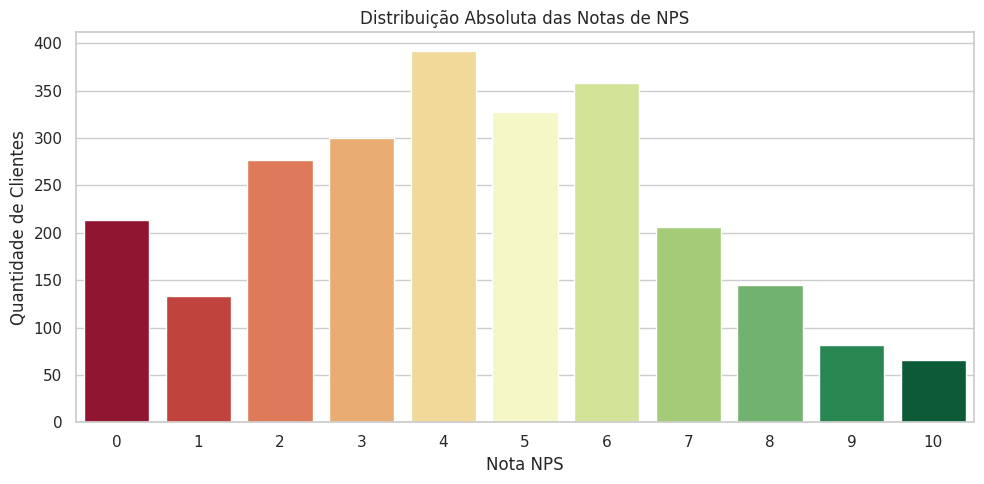

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# 1. Converte/arredonda as notas para inteiros evitando barras decimais redundantes
df_plot = df_nps.copy()
df_plot['nps_score'] = df_plot['nps_score'].round().astype(int)

# 2. 'RdYlGn' (ou 'coolwarm_r') garante o vermelho nas notas baixas (esquerda)
sns.countplot(
    data=df_plot,
    x='nps_score',
    palette='RdYlGn',
    hue='nps_score',
    legend=False
)

plt.title('Distribuição Absoluta das Notas de NPS')
plt.xlabel('Nota NPS')
plt.ylabel('Quantidade de Clientes')

plt.tight_layout()
plt.show()

Perceba que aparentemente boa parte dos detratores se encontra com nota entre 4 e 6 que é um intervalo mais possível de subir para pelomenos 7 do que por exemplo os detratores entre 0 e 3.

In [58]:
def categorize_detrator(score):
    if score >= 4:
        return 'Detrator com potencial'
    else:
        return 'Detrator'

In [59]:
# 1. Filtra apenas os registros onde is_detractor é True
df_detrator = df_nps[df_nps['is_detractor'] == True].copy()

# 2. Aplica a função usando a coluna 'nps_score' para sobrescrever 'nps_grupo'
df_detrator['nps_grupo'] = df_detrator['nps_score'].apply(categorize_detrator)

In [60]:
df_detrator['nps_grupo'].value_counts()

,count
nps_grupo,
Detrator,1088
Detrator com potencial,1021


In [61]:
# Proporção dentro do df de detratores
pct_sobre_detratores = (df_detrator['nps_grupo'] == 'Detrator com potencial').mean() * 100

print(f"{pct_sobre_detratores:.2f}% dos detratores são 'Detrator com potencial'")

48.41% dos detratores são 'Detrator com potencial'


De fato 48.41% dos detrator estão com nota acima de 4 o que indica que temos 1021 cliente que tem um potencial maior de subir para um cliente passivo.

In [62]:
df_nps_so_nps = df_nps[['nps_score']]
df_nps_so_nps.describe().round(2)

,nps_score
count,2500.00
mean,4.38
std,2.51
min,0.00
25%,2.60
50%,4.40
75%,6.10
max,10.00


Perceba que o NPS em geral é bem baixo, com a média sendo 4.38 e 75% dos clientes tendo um nps menór que 6.10.

Agora vamos começar a análisar a relação do NPS com cada uma das etapas da jornada de compra.

Começando pela logistica

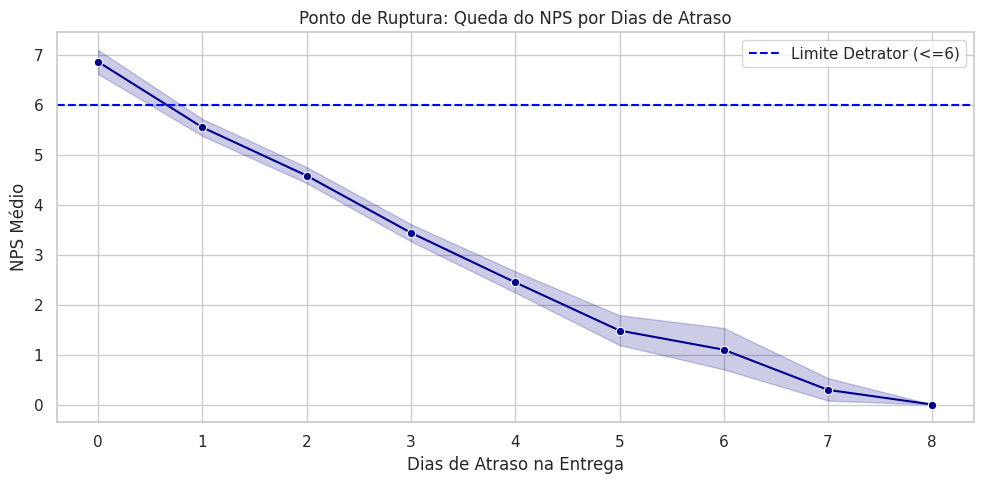

In [90]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_nps, x='delivery_delay_days', y='nps_score', marker='o', color='darkblue')
plt.axhline(6, color='blue', linestyle='--', label='Limite Detrator (<=6)')
plt.title('Ponto de Ruptura: Queda do NPS por Dias de Atraso')
plt.xlabel('Dias de Atraso na Entrega')
plt.ylabel('NPS Médio')
plt.legend()
plt.tight_layout()
plt.show()

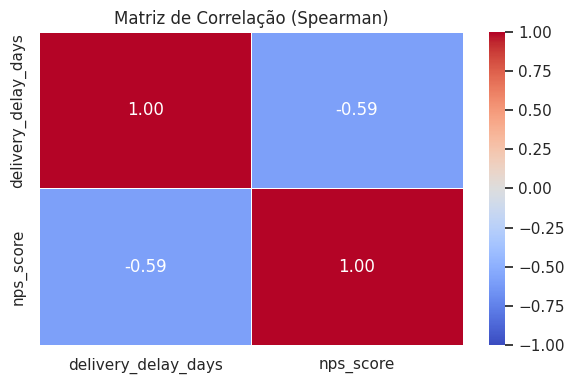

In [64]:
df_diatraso = df_nps[['delivery_delay_days', 'nps_score']].corr(method='spearman')

plt.figure(figsize=(6, 4))
sns.heatmap(df_diatraso, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Matriz de Correlação (Spearman)')
plt.tight_layout()
plt.show()

é Possível perceber um recorte importante, que qualquer atráso na entrega afeta bastante o nps

In [65]:
# NPS médio e quantidade (count) para cada quantidade de dias de atraso
nps_medio_por_atraso = df_nps.groupby('delivery_delay_days')['nps_score'].agg(
    nps_medio='mean',
    quantidade='count'
).reset_index()

print(nps_medio_por_atraso)

# Consulta rápida (com média e contagem) para 0 e 3 dias de atraso
dados_0_dias = df_nps[df_nps['delivery_delay_days'] == 0]['nps_score']
dados_3_dias = df_nps[df_nps['delivery_delay_days'] == 3]['nps_score']

print(f"0 dias de atraso: NPS médio = {dados_0_dias.mean():.2f} (Total: {dados_0_dias.count()})")
print(f"3 dias de atraso: NPS médio = {dados_3_dias.mean():.2f} (Total: {dados_3_dias.count()})")

   delivery_delay_days  nps_medio  quantidade
0                    0   6.856679         277
1                    1   5.546179         615
2                    2   4.580186         646
3                    3   3.436762         525
4                    4   2.444444         270
5                    5   1.481034         116
6                    6   1.097059          34
7                    7   0.292857          14
8                    8   0.000000           3
0 dias de atraso: NPS médio = 6.86 (Total: 277)
3 dias de atraso: NPS médio = 3.44 (Total: 525)


De fato é possível perceber que, para valores até 5, um dia de atraso chega a diminuir em aproximademente um ponto o nps médio q.

In [66]:
df_nps['delivery_delay_days'].value_counts()

,count
delivery_delay_days,
2,646
1,615
3,525
0,277
4,270
5,116
6,34
7,14
8,3


In [67]:
(df_nps['delivery_delay_days'].value_counts(normalize=True) * 100).round(2)

,proportion
delivery_delay_days,
2,25.84
1,24.60
3,21.00
0,11.08
4,10.80
5,4.64
6,1.36
7,0.56
8,0.12


E ainda esse tópico se torna ainda mais importante haja vista que apenas 11% das nossas entregas não atrasam.

In [68]:
df_nps.groupby('nps_arredondado')['delivery_delay_days'].agg(['mean', 'count'])

,mean,count
nps_arredondado,,
0,3.971831,213
1,3.443609,133
2,3.046931,277
3,2.430000,300
4,2.176020,392
5,1.926829,328
6,1.617318,358
7,1.393204,206
8,0.910345,145


Porém vale resaltar que não é uma verdade absoluta, pois o nps médio para 0 dias de entrega é 6.8, ou seja sem atrazo na entrega não garante nps alto.

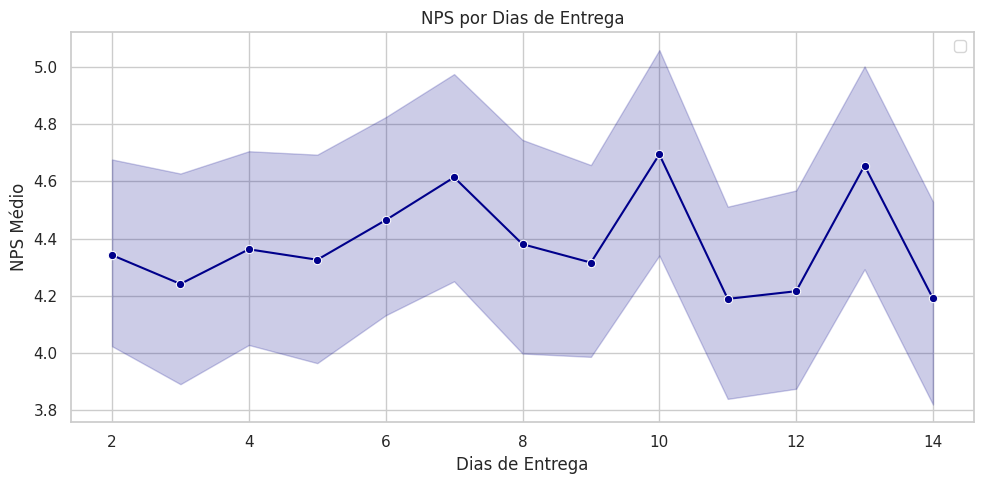

In [91]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_nps, x='delivery_time_days', y='nps_score', marker='o', color='darkblue')
plt.title('NPS por Dias de Entrega')
plt.xlabel('Dias de Entrega')
plt.ylabel('NPS Médio')
plt.legend()
plt.tight_layout()
plt.show()

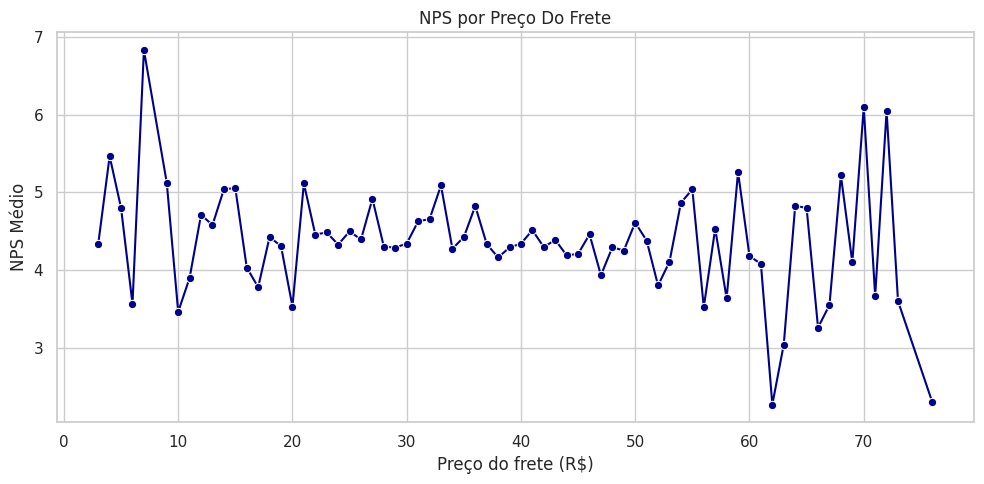

In [92]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_nps.assign(freight_rounded=df_nps['freight_value'].round(0)),
    x='freight_rounded',
    y='nps_score',
    marker='o',
    color='darkblue',
    errorbar=None
)
plt.title('NPS por Preço Do Frete')
plt.xlabel('Preço do frete (R$)')
plt.ylabel('NPS Médio')
plt.tight_layout()
plt.show()

Agora a relação do NPS com o preço do frete ou o prazo do frete já não parece ter uma correlação tão forte quanto o atrazo na entrega.

#SAC

In [71]:
df_SAC = df_nps[['nps_score','resolution_time_days','customer_service_contacts','complaints_count','nps_grupo']]
df_SAC.describe().round(2)

,nps_score,resolution_time_days,customer_service_contacts,complaints_count
count,2500.00,2500.00,2500.00,2500.00
mean,4.38,5.49,1.52,4.15
std,2.51,3.46,1.23,1.78
min,0.00,0.00,0.00,0.00
25%,2.60,2.00,1.00,3.00
50%,4.40,6.00,1.00,4.00
75%,6.10,8.00,2.00,5.00
max,10.00,11.00,7.00,11.00


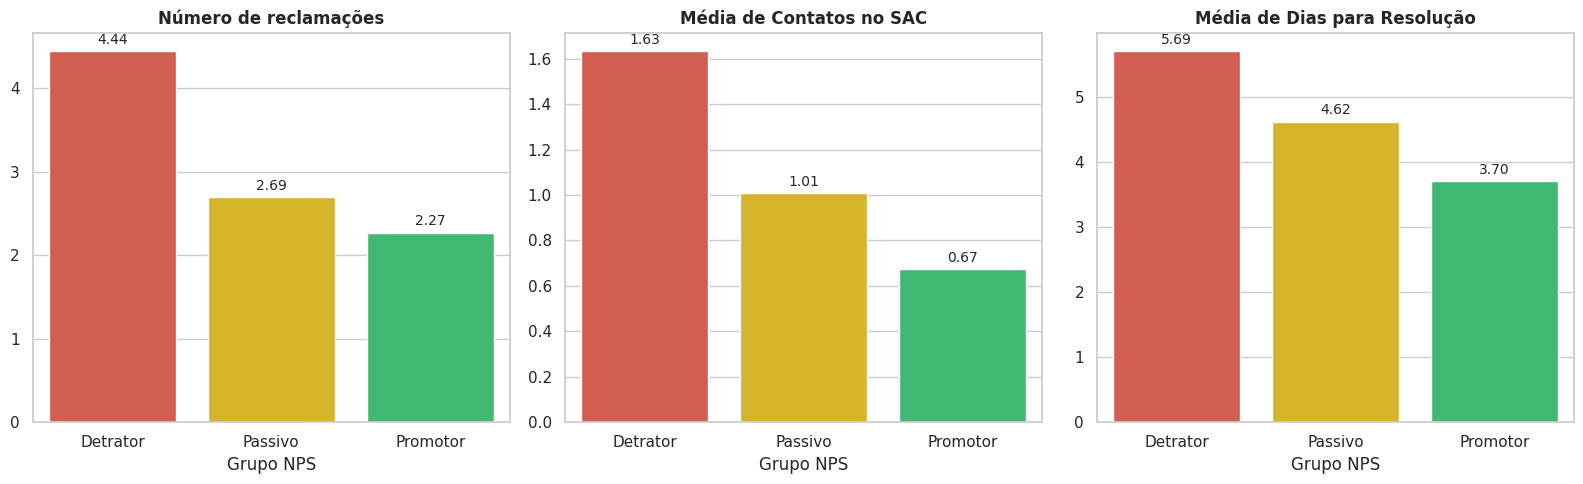

In [95]:
colunas_metricas = ['complaints_count', 'customer_service_contacts', 'resolution_time_days']
titulos = ['Número de reclamações', 'Média de Contatos no SAC', 'Média de Dias para Resolução']

# Definindo ordem das colunas no eixo X e suas respectivas cores
ordem_nps = ['Detrator', 'Passivo', 'Promotor']
cores_nps = ['#e74c3c', '#f1c40f', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(colunas_metricas):
    sns.barplot(
        data=df_SAC,
        x='nps_grupo',
        y=col,
        ax=axes[i],
        order=ordem_nps,
        hue='nps_grupo',
        palette=cores_nps,
        errorbar=None
    )
    axes[i].set_title(titulos[i], fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Grupo NPS')
    axes[i].set_ylabel('')

    # Adiciona os rótulos com os valores exatos no topo de cada barra
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0:
            axes[i].annotate(
                f'{height:.2f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points'
            )

plt.tight_layout()
plt.show()

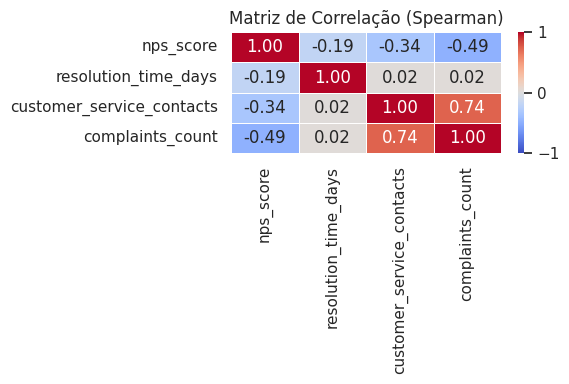

In [73]:
plt.figure(figsize=(6, 4))
matriz_corr = df_SAC.drop(columns=['nps_grupo']).corr(method='spearman')

# 'coolwarm' totalmente em minúsculo
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Matriz de Correlação (Spearman)')
plt.tight_layout()
plt.show()

Agora é possível perceber uma correlação forte entre a quantidade de reclamações do cliente e a baixa do NPS, com a média de reclamações entre os clientes detratores é 4,4 enquanto entre os clientes passivos e promotores está entre 2,7 e 2,2. Consequentemente também deve ser levado em consideração a quantidade de contatos do cliente com o suporte, pois está relacionado com as reclamações.

In [99]:
dist_contatos = (
    df_SAC.groupby('customer_service_contacts')
    .agg(
        Qtd_Clientes=('nps_score', 'count'),
        NPS_Medio=('nps_score', 'mean'),
    )
    .reset_index()
)

dist_contatos['%_Total'] = (
    dist_contatos['Qtd_Clientes'] / dist_contatos['Qtd_Clientes'].sum() * 100
)

# Reordenando e formatando as colunas
dist_contatos = dist_contatos.set_index('customer_service_contacts')
dist_contatos = dist_contatos[['Qtd_Clientes', '%_Total', 'NPS_Medio']].round(
    2
)
print('--- Distribuição de Contatos ---')
print(dist_contatos)

--- Distribuição de Contatos ---
                           Qtd_Clientes  %_Total  NPS_Medio
customer_service_contacts                                  
0                                   554    22.16       5.54
1                                   816    32.64       4.66
2                                   640    25.60       4.12
3                                   314    12.56       3.20
4                                   132     5.28       2.65
5                                    34     1.36       2.24
6                                     7     0.28       0.74
7                                     3     0.12       1.20


In [101]:
dist_reclamacoes = (
    df_SAC.groupby('complaints_count')
    .agg(
        Qtd_Clientes=('nps_score', 'count'),
        NPS_Medio=('nps_score', 'mean'),
    )
    .reset_index()
)

dist_reclamacoes['%_Total'] = (
    dist_reclamacoes['Qtd_Clientes'] / dist_reclamacoes['Qtd_Clientes'].sum()
) * 100

# Reordenando e formatando as colunas
dist_reclamacoes = dist_reclamacoes.set_index('complaints_count')
dist_reclamacoes = dist_reclamacoes[
    ['Qtd_Clientes', '%_Total', 'NPS_Medio']
].round(2)

print('\n--- Distribuição de Reclamações ---')
print(dist_reclamacoes)


--- Distribuição de Reclamações ---
                  Qtd_Clientes  %_Total  NPS_Medio
complaints_count                                  
0                           23     0.92       8.52
1                          122     4.88       7.77
2                          277    11.08       6.05
3                          507    20.28       4.91
4                          600    24.00       4.22
5                          444    17.76       3.65
6                          266    10.64       3.06
7                          169     6.76       2.81
8                           63     2.52       2.07
9                           16     0.64       2.49
10                          11     0.44       2.28
11                           2     0.08       0.85


In [75]:
# Tabela de dupla entrada (frequência absoluta)
matriz_contatos_reclamacoes = pd.crosstab(
    df_SAC["customer_service_contacts"],
    df_SAC["complaints_count"],
    margins=True,
    margins_name="Total",
)

# Resumo dos cenários específicos
tot_clientes = len(df_SAC)

so_contatos = (
    (df_SAC["customer_service_contacts"] > 0) & (df_SAC["complaints_count"] == 0)
).sum()
so_reclamacoes = (
    (df_SAC["customer_service_contacts"] == 0) & (df_SAC["complaints_count"] > 0)
).sum()
ambos = (
    (df_SAC["customer_service_contacts"] > 0) & (df_SAC["complaints_count"] > 0)
).sum()
nenhum = (
    (df_SAC["customer_service_contacts"] == 0) & (df_SAC["complaints_count"] == 0)
).sum()

resumo_grupos = pd.DataFrame(
    {
        "Grupo": [
            "Apenas Contatos (sem reclamação)",
            "Apenas Reclamações (sem contato)",
            "Ambos (Contatos e Reclamações)",
            "Nenhum (0 contatos e 0 reclamações)",
        ],
        "Qtd": [so_contatos, so_reclamacoes, ambos, nenhum],
        "%_Total": [
            round((so_contatos / tot_clientes) * 100, 2),
            round((so_reclamacoes / tot_clientes) * 100, 2),
            round((ambos / tot_clientes) * 100, 2),
            round((nenhum / tot_clientes) * 100, 2),
        ],
    }
)

print(matriz_contatos_reclamacoes)
print("\n", resumo_grupos)

complaints_count            0    1    2    3    4    5    6    7   8   9  10  \
customer_service_contacts                                                      
0                          23   91  182  136   92   22    7    0   1   0   0   
1                           0   31   82  304  247  110   27   13   2   0   0   
2                           0    0   13   63  236  204   80   36   8   0   0   
3                           0    0    0    4   24  106  102   61  15   2   0   
4                           0    0    0    0    1    2   49   41  24  10   5   
5                           0    0    0    0    0    0    1   18  10   3   1   
6                           0    0    0    0    0    0    0    0   3   0   4   
7                           0    0    0    0    0    0    0    0   0   1   1   
Total                      23  122  277  507  600  444  266  169  63  16  11   

complaints_count           11  Total  
customer_service_contacts             
0                           0    554  
1 

A correlação das reclamações e a baixa do nps se torna ainda mais preocupante quando apenas 0,92% dos nossos clientes não possuem reclamações. Além disso nenhum cliente entrou em contato e não fez reclamações, ou seja não podemos esperar que algum cliente entre em contato para tentarmos resolver, se ele fizer o primeiro contato a situação já é problemática e muito possívelmente acaretará em uma reclamação.

# Agora vamos análisar o que pode ser feito ao detectar um caso que pode virar um baixo NPS

Durante a operanção ao se verificar que um cliente terá um nps baixo é de se imaginar que por exemplo dar um desconto em próximas compras é vantajoso, mas será mesmo?

In [80]:
df_nps['discount_pct'] = np.where(df_nps['order_value'] > 0,
                                  (df_nps['discount_value'] / df_nps['order_value']) * 100,
                                  0) # Handle division by zero
display(df_nps.head())

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,...,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_grupo,is_detractor,nps_arredondado,discount_pct
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,...,0,4,6.9,0,3,6.5,Detrator,1,7,28.161454
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,...,0,10,2.4,0,3,0.0,Detrator,1,2,2.072121
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,...,4,5,4.8,0,7,1.5,Detrator,1,5,8.444760
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,...,1,11,5.9,0,4,0.3,Detrator,1,6,6.479367
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,...,1,0,6.1,0,3,7.9,Detrator,1,6,11.605943


In [81]:
correlacoes = df_nps.corr(numeric_only=True)['nps_score'].sort_values()
print(correlacoes)

is_detractor                -0.672592
delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
freight_value               -0.041087
customer_age                -0.009936
customer_tenure_months      -0.009711
discount_pct                -0.009399
delivery_time_days           0.000925
items_quantity               0.011468
payment_installments         0.023718
discount_value               0.025104
delivery_attempts            0.027680
order_value                  0.036990
csat_internal_score          0.563952
repeat_purchase_30d          0.570324
nps_arredondado              0.993911
nps_score                    1.000000
Name: nps_score, dtype: float64


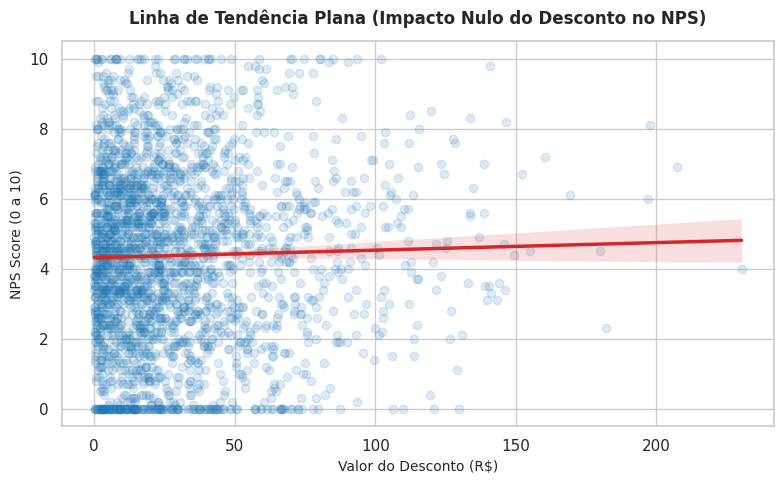

In [77]:
# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Gráfico de Tendência (Scatter + Regressão Linear)
ax = sns.regplot(
    data=df_nps,
    x='discount_value',
    y='nps_score',
    scatter_kws={'alpha': 0.15, 'color': '#1f77b4'},
    line_kws={'color': '#d62728', 'linewidth': 2.5},
)

# Ajustes de título e eixos
ax.set_title('Linha de Tendência Plana (Impacto Nulo do Desconto no NPS)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Valor do Desconto (R$)', fontsize=10)
ax.set_ylabel('NPS Score (0 a 10)', fontsize=10)
ax.set_ylim(-0.5, 10.5)

plt.tight_layout()
plt.show()

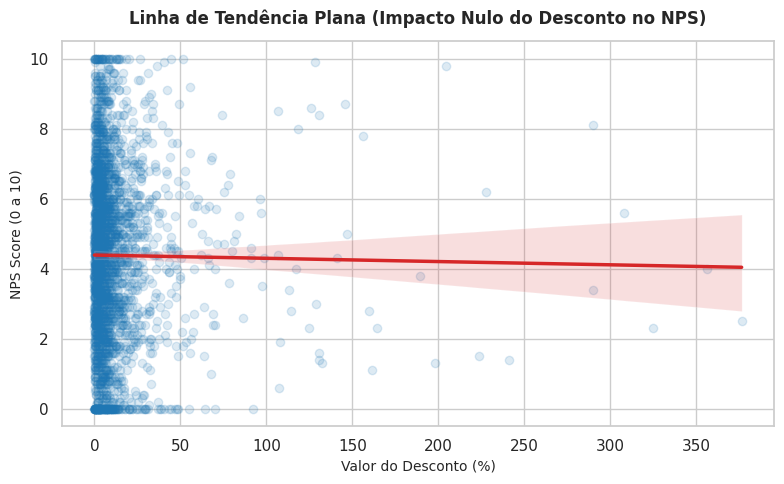

In [87]:
# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Gráfico de Tendência (Scatter + Regressão Linear)
ax = sns.regplot(
    data=df_nps,
    x='discount_pct',
    y='nps_score',
    scatter_kws={'alpha': 0.15, 'color': '#1f77b4'},
    line_kws={'color': '#d62728', 'linewidth': 2.5},
)

# Ajustes de título e eixos
ax.set_title('Linha de Tendência Plana (Impacto Nulo do Desconto no NPS)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Valor do Desconto (%)', fontsize=10)
ax.set_ylabel('NPS Score (0 a 10)', fontsize=10)
ax.set_ylim(-0.5, 10.5)

plt.tight_layout()
plt.show()

In [86]:
display(df_nps['discount_pct'].describe())

high_discount_pct_rows = df_nps[df_nps['discount_pct'] > 100]
display(high_discount_pct_rows[['order_value', 'discount_value', 'discount_pct','nps_score']].sort_values(by='discount_pct', ascending=False))

,discount_pct
count,2500.000000
mean,12.519645
std,25.416173
min,0.004161
25%,2.091864
50%,5.719629
75%,12.856775
max,376.417526


,order_value,discount_value,discount_pct,nps_score
880,7.76,29.21,376.417526,2.5
182,24.00,85.49,356.208333,4.0
2456,30.68,99.74,325.097784,2.3
717,27.01,83.21,308.071085,5.6
908,12.13,35.19,290.107172,3.4
1404,68.20,197.60,289.736070,8.1
6,41.29,99.62,241.269072,1.4
1019,23.06,52.52,227.753686,6.2
1818,28.41,63.62,223.935234,1.5
1363,68.85,140.73,204.400871,9.8


Analisando os dados é possível perceber que discontos não são uma garantia de NPS alto. Inclusive a empresa chega a oferecer descontos que ultrapassam o valor original da compra e mesmo assim recebe pesquisas baixas. Isso não quer dizer que a politica atual de descontes deva parar abruptamente, pois o resultado dessa interrupção não é trivial e deve ser estudado em outro trabalho, só queremos enfatizar que também não é uma solução linear para o aumente do NPS distribuir descontos.

# Agora vamos entender o impacto financeiro direto no negócio

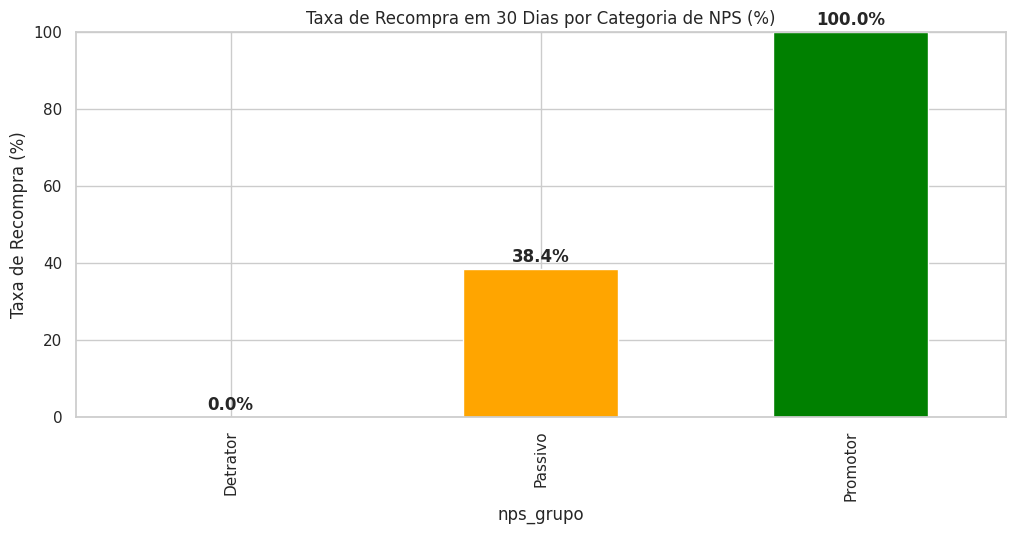

In [88]:
# Taxa de Recompra em 30 dias por Grupo de NPS
recompra_nps = df_nps.groupby('nps_grupo')['repeat_purchase_30d'].mean() * 100

plt.figure(figsize=(12, 5))
recompra_nps.reindex(['Detrator', 'Passivo', 'Promotor']).plot(kind='bar', color=['red', 'orange', 'green'])
plt.title('Taxa de Recompra em 30 Dias por Categoria de NPS (%)')
plt.ylabel('Taxa de Recompra (%)')
plt.ylim(0, 100)

for i, v in enumerate(recompra_nps.reindex(['Detrator', 'Passivo', 'Promotor'])):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.show()

Por fim gostariamos de destacar que melhor a satisfação dos nossos clientes é importante, haja vista que nenhum detrator volta a comprar conosco e que esse representa um total de 84% dos nossos clientes, enquanto os promotores que sempre voltam são só 4%


